In [83]:
!pip install hdbscan

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import hdbscan

In [85]:
df = pd.read_csv("M41_query_result_full.csv")

print("Número de estrellas:", len(df))
df.head()

Número de estrellas: 28196


,random_index,source_id,ra,dec,parallax,parallax_over_error,pmdec,pmdec_error,pmra,pmra_error,ruwe,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp
0,1381651595,2926059827481255680,101.871514,-21.638468,0.708287,15.724628,-4.061186,0.041292,-0.045740,0.029029,1.055384,16.628632,17.203814,15.902876,1.300938
1,226379506,2926062576260337408,101.791043,-21.639748,0.856612,6.924300,-2.894021,0.112050,1.558011,0.080318,0.975567,18.450891,19.332483,17.522280,1.810204
2,741620331,2926062610615673472,101.767416,-21.651002,2.363314,1.571006,11.480609,1.119343,9.070124,0.716237,1.118750,20.810562,21.877844,19.674230,2.203613
3,1021135133,2926062919857705472,101.840912,-21.604856,1.955211,113.311530,-35.483904,0.015670,-11.917450,0.011108,1.002468,14.496161,14.930145,13.892927,1.037218
4,340816657,2926061614178561024,101.706995,-21.683744,0.868512,2.326162,2.742589,0.346593,2.426535,0.208912,1.020591,19.892107,20.634743,18.969057,1.665686


In [86]:
features = df[[
    "ra",
    "dec",
    "parallax",
    "pmra",
    "pmdec"
]].dropna()

In [87]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10
)

labels = clusterer.fit_predict(X)

features["cluster"] = labels

In [89]:
print("Clusters encontrados:", np.unique(labels))

Clusters encontrados: [-1  0  1]


In [90]:
cluster_counts = features["cluster"].value_counts()

print(cluster_counts)

clusters = features["cluster"].unique()
clusters = clusters[clusters != -1]  # quitar ruido

best_cluster = None
best_dispersion = np.inf

for c in clusters:
    subset = features[features["cluster"] == c]

    dispersion = subset["pmra"].std() + subset["pmdec"].std()

    if dispersion < best_dispersion:
        best_dispersion = dispersion
        best_cluster = c

print("Cluster seleccionado:", best_cluster)

cluster_stars = features[features["cluster"] == best_cluster]
members = df.loc[cluster_stars.index]

cluster
-1    19241
 1     7924
 0     1031
Name: count, dtype: int64
Cluster seleccionado: 0


In [91]:
cluster_indices = cluster_stars.index

members = df.loc[cluster_indices]

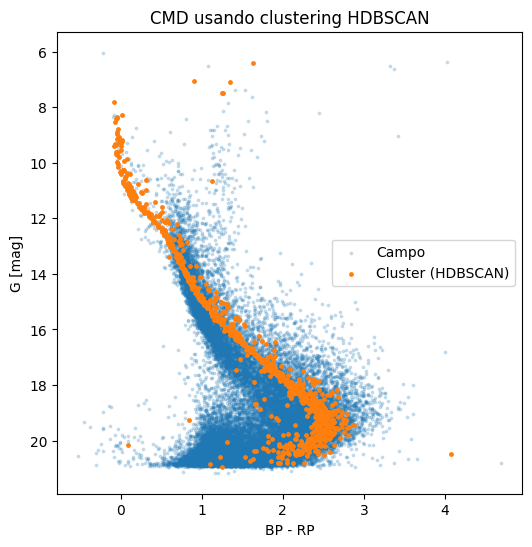

In [92]:
plt.figure(figsize=(6,6))

plt.scatter(
    df["bp_rp"],
    df["phot_g_mean_mag"],
    s=3,
    alpha=0.2,
    label="Campo"
)

plt.scatter(
    members["bp_rp"],
    members["phot_g_mean_mag"],
    s=6,
    label="Cluster (HDBSCAN)"
)

plt.gca().invert_yaxis()

plt.xlabel("BP - RP")
plt.ylabel("G [mag]")
plt.title("CMD usando clustering HDBSCAN")

plt.legend()

plt.show()